In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import sklearn.gaussian_process as gp
import os
from IPython.display import display, Math

import sympy as sp
sys.path.append('../nn_model')
sys.path.append('..')
sys.path.append('../data')

sys.path.append('GP_regr')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
import SR_lib

import nn_model_lib as _lib

from nn_model_lib import *


def import_reload():
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)

import_reload()

/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
RUN_ID = 'test3'
DT = 1
Q0 = 17921.57581 

REF_VALUES  = SR_lib.get_ref_values(run_id=RUN_ID)


VARIABLES = ['R0', 'R1', 'C1','k','sdot','Ue']
REF_VALUES = SR_lib.get_ref_values(run_id=RUN_ID)

UNITS, UNIT_CONV = SR_lib.get_units_dict()
LATEX_DICT = SR_lib.get_latex_dict()

SELECTION = "best"

In [3]:
model_name = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'

BAT_MODEL, ckpt = load_nn_model(model_name)

def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)
# diff_vals = data.max(axis=0) - data.min(axis=0)
# print(diff_vals)

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'false', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'false', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'false', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'false', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using Q0_ckpt = 17921.57581, I_ref = 24.89107751102174 and u_ref = 4.297601866251944 for model parameters
k unconstrained
ds/dt unconstrained  (dynamic sdotNet)
R1 unconstrained
C1 unconstrained
R0 unconstrained


In [4]:
print(f"Loading symbolic regression results for RUN_ID: {RUN_ID}")

expressions = SR_lib.extract_expressions(RUN_ID)
R0_expr = expressions['R0']
R1_expr = expressions['R1']
C1_expr = expressions['C1']
k_expr = expressions['k']
sdot_expr = expressions['sdot']

latent_variables = {'x0': 'c-rate', 'x1': 'd_per', 'x2': 'soc', 'x3':'s'}


from collections import Counter

symbol_counts = {}
for elem in VARIABLES:
    counter = Counter()
    for expr in expressions[elem]:
        sympy_expr = sp.sympify(expr)

        counter.update(map(str, sympy_expr.free_symbols))

    symbol_counts[elem] = counter

# convert to dataframe for better visualization
symbol_counts_df = pd.DataFrame(symbol_counts).fillna(0).astype(int)

for elem in symbol_counts_df:
    symbol_counts_df[elem] = 100 * symbol_counts_df[elem] / expressions[elem].shape[0]

df_symcounts = symbol_counts_df.transpose()
display(df_symcounts)
df_symcounts.columns = [latent_variables.get(col, col) for col in df_symcounts.columns]

# round values to 1 decimal place
df_symcounts = df_symcounts.round(1)

def df_latex_table(df, caption=None, label=None):
    latex_str = df.to_latex(index=True, escape=False)
    if caption:
        latex_str = latex_str.replace('\\begin{tabular}', f'\\begin{{table}}[ht]\n\\centering\n\\caption{{{caption}}}\n\\begin{{tabular}}')
    if label:
        latex_str = latex_str.replace('\\end{tabular}', f'\\end{{tabular}}\n\\label{{{label}}}\n\\end{{table}}')
    return latex_str

latex_table = df_latex_table(df_symcounts, caption="Symbol usage percentages in SR expressions", label="tab:symbol_usage")
# print(latex_table)


Loading symbolic regression results for RUN_ID: test3


,soc,C,d,s
R0,92.857143,64.285714,50.000000,0.000000
R1,84.615385,61.538462,0.000000,0.000000
C1,93.333333,53.333333,0.000000,0.000000
k,58.333333,0.000000,91.666667,0.000000
sdot,7.692308,92.307692,76.923077,7.692308
Ue,93.750000,0.000000,0.000000,0.000000


In [5]:
# Normalization the SR fits expect at their inputs.
# Update these if you retrain SR with a different feature range.
SR_C_NORM = 5.0     # c_rate trained on c_rate / 5
SR_D_NORM = 30.0    # u_per  trained on u_per  / 30

# ── element registry (single source of truth) ──────────────────────────
_ELEM_META = {
    'R0': (UNIT_CONV['R0'], f'${LATEX_DICT['R0']}$ [{UNITS['R0']}]'),
    'R1': (UNIT_CONV['R1'], f'${LATEX_DICT['R1']}$ [{UNITS['R1']}]'),
    'C1': (UNIT_CONV['C1'], f'${LATEX_DICT['C1']}$ [{UNITS['C1']}]'),
    'k': (UNIT_CONV['k'], f'${LATEX_DICT['k']}$ [{UNITS['k']}]'),
    'sdot': (UNIT_CONV['sdot'], f'${LATEX_DICT['sdot']}$ [{UNITS['sdot']}]'),
    's': (UNIT_CONV['s'], f'${LATEX_DICT['s']}$ [{UNITS['s']}]'),
    'Ue': (UNIT_CONV['Ue'], f'${LATEX_DICT['Ue']}$ [{UNITS['Ue']}]')
}

chosen_SR, best_SR = SR_lib.get_SR_inds(RUN_ID)

sr_model_name = f"SR-chosen-{RUN_ID}"
print(f'SR model name: {sr_model_name}')

sr_expr = best_SR   # Choose which SR expressions to use for plotting

C1_expr = expressions['C1'][sr_expr['C1']]
R0_expr = expressions['R0'][sr_expr['R0']]
R1_expr = expressions['R1'][sr_expr['R1']]
k_expr = expressions['k'][sr_expr['k']]
sdot_expr = expressions['sdot'][sr_expr['sdot']]

R0_func = sp.lambdify(('C', 'd', 'soc'), R0_expr, 'numpy')
k_func = sp.lambdify(('C', 'd', 'soc'), k_expr, 'numpy')
R1_func = sp.lambdify(('C', 'd', 'soc'), R1_expr, 'numpy')
C1_func = sp.lambdify(('C', 'd', 'soc'), C1_expr, 'numpy')
sdot_func = sp.lambdify(('C', 'd', 'soc', 's'), sdot_expr, 'numpy')

def _compute_element(element, c_rate, u_per, soc_t, source='nn'):
    """source is 'nn','sr'. s/sdot always use sdot_nn (no SR variant yet)."""
    # SR functions were trained on normalized inputs; NN handles its own norm.
    if source == 'sr':
        c_arg, u_arg = c_rate / REF_VALUES['C'], u_per / REF_VALUES['d']
        funcs = {'R0': R0_func, 'R1': R1_func, 'C1': C1_func, 'k': k_func}
    elif source == 'nn':
        c_arg, u_arg = c_rate, u_per
        funcs = {'R0': R0_nn, 'R1': R1_nn, 'C1': C1_nn, 'k': k_nn}
    else:
        raise ValueError(f"source must be 'nn' or 'sr', got {source!r}")

    if element in funcs:
        return funcs[element](c_arg, u_arg, soc_t)

    if element == 'tau':
        return (funcs['R1'](c_arg, u_arg, soc_t) * funcs['C1'](c_arg, u_arg, soc_t))
    if element in ('s', 'sdot'):
        s_curr = 0.0
        out = []
        dsoc = float(abs(soc_t[1] - soc_t[0]))
        dt = dsoc * 3600.0 / c_rate

        for soc_val in soc_t:
            if source == 'sr':
                s_in = s_curr / REF_VALUES['s']                       # state → normalized
                ds_norm = float(np.asarray(
                    sdot_func(c_arg, u_arg, soc_val, s_in)).squeeze())
                ds_phys = ds_norm * REF_VALUES['sdot']                # → physical for the integrator
            else:
                ds_phys = float(np.asarray(
                    sdot_nn(c_rate, u_per, soc_val, s_curr)).squeeze())

            if element == 'sdot':
                out.append(ds_phys / REF_VALUES['sdot'] if source == 'sr' else ds_phys)
            s_curr = s_curr + ds_phys * dt
            if element == 's':
                out.append(s_curr / REF_VALUES['s'] if source == 'sr' else s_curr)

        return np.asarray(out)

    raise ValueError(f"unknown element {element!r}")


# ── per-axis draw, possibly two sources overlaid ────────────────────────
_LINESTYLE = {'nn': '--', 'sr': '-'}   # NN dashed, SR solid

def _draw_sweep(ax, element, *, sweep, fixed, sweep_vals, soc_t,
                cmap_obj, norm, models='nn'):
    """models in {'nn','sr','both'}.  When 'both', NN is dashed, SR is solid."""
    scale_nn, ylabel = _ELEM_META[element]
    scale_sr = REF_VALUES[element]

    if models == 'both':
        sources = ['nn', 'sr']
    elif models in ('nn', 'sr'):
        sources = [models]
    else:
        raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")

    # If only one source, use solid regardless of which it is
    styles = _LINESTYLE if len(sources) == 2 else {sources[0]: '-'}

    for val in sweep_vals:
        c_rate, u_per = (fixed, val) if sweep == 'u_per' else (val, fixed)
        color = cmap_obj(norm(val))
        for src in sources:
            y = _compute_element(element, c_rate, u_per, soc_t, source=src)
            if src == 'nn':
                y_disp = y * scale_nn
            elif src == 'sr':
                y_disp = y * scale_sr * scale_nn

            ax.plot(soc_t.numpy(), y_disp, color=color, lw=2, linestyle=styles[src])

    ax.set_ylabel(ylabel)
    ax.ticklabel_format(useOffset=False, style='plain', axis='y')

def _make_cmap(name):
    base = {'Blues': plt.cm.Blues_r, 'Reds': plt.cm.Reds_r}[name]
    return LinearSegmentedColormap.from_list(
        f"{name}_custom", base(np.linspace(0.0, 0.8, 256)))

# ── grid  ───────────────────────────────────────────────────
def plot_element_grid(elements, *, models='nn',
                      fixed_C=2.5, fixed_d=15.0,
                      d_sweep_vals=None, c_sweep_vals=None,
                      soc=None, figsize=None):
    """
    2  len(elements) grid.
        Top row    : fixed d, sweep C  (Blues, C-rate colorbar)
        Bottom row : fixed C, sweep d  (Reds,  d colorbar)
    models : 'nn' | 'sr' | 'both'.  When 'both', NN is dashed and SR is solid.
    """
    if models not in ('nn', 'sr', 'both'):
        raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")

    if d_sweep_vals is None:
        d_sweep_vals = np.linspace(0, 30, 6)
    if c_sweep_vals is None:
        c_sweep_vals = np.array([0.5, 1, 2, 3, 4, 5])
        # c_sweep_vals = np.linspace(0.0, 5.0, 6)
    if soc is None:
        soc = np.linspace(1.0, 0.1, 100)
    soc_t = torch.as_tensor(soc, dtype=torch.float32)

    n = len(elements)
    if figsize is None:
        figsize = ((3.5 * n + 1) if n == 1 else (3.5 * n), 5)

    fig, axes = plt.subplots(2, n, figsize=figsize,
                              sharex=True, constrained_layout=True)
    if n == 1:
        axes = axes.reshape(2, 1)

    cmap_red, cmap_blue = _make_cmap('Reds'), _make_cmap('Blues')
    norm_d = Normalize(vmin=d_sweep_vals.min(), vmax=d_sweep_vals.max())
    norm_C = Normalize(vmin=c_sweep_vals.min(), vmax=c_sweep_vals.max())

    for j, elem in enumerate(elements):
        _draw_sweep(axes[1, j], elem, sweep='u_per', fixed=fixed_C,
                    sweep_vals=d_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_red, norm=norm_d, models=models)
        _draw_sweep(axes[0, j], elem, sweep='c_rate', fixed=fixed_d,
                    sweep_vals=c_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_blue, norm=norm_C, models=models)

    for ax in axes[1, :]:
        ax.set_xlabel('State of Charge')

    sm_d = ScalarMappable(cmap=cmap_red,  norm=norm_d); sm_d.set_array([])
    sm_C = ScalarMappable(cmap=cmap_blue, norm=norm_C); sm_C.set_array([])
    fig.colorbar(sm_d, ax=axes[1, :].tolist(),
                 label=r'$\widetilde{d}$ [\%]', location='right', pad=0.01)
    fig.colorbar(sm_C, ax=axes[0, :].tolist(),
                 label='C-rate [1/h]', location='right', pad=0.01)

    # Fixed-value tags
    axes[1, 0].legend(
        handles=[plt.Line2D([0], [0], color='none', label=fr'${fixed_C:g}$C')], loc='best', frameon=True, handlelength=0, handletextpad=0)
    axes[0, 0].legend(
        handles=[plt.Line2D([0], [0], color='none', label=fr'$\widetilde{{d}} = {fixed_d:g}\%$')],
        loc='best', frameon=True, handlelength=0, handletextpad=0)

    # Linestyle key — only when both sources are overlaid
    if models == 'both':
        axes[0, -1].legend(
            handles=[
                plt.Line2D([0], [0], color='gray', linestyle='--', lw=2, label='NN'),
                plt.Line2D([0], [0], color='gray', linestyle='-',  lw=2, label='SR'),
            ],
            loc='best', frameon=True)

    return fig

SR model name: SR-chosen-test3


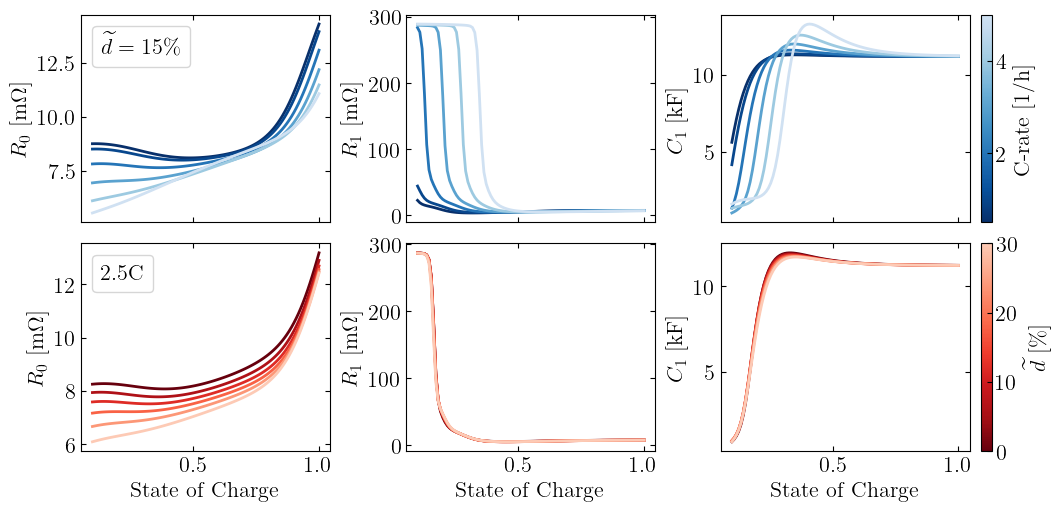

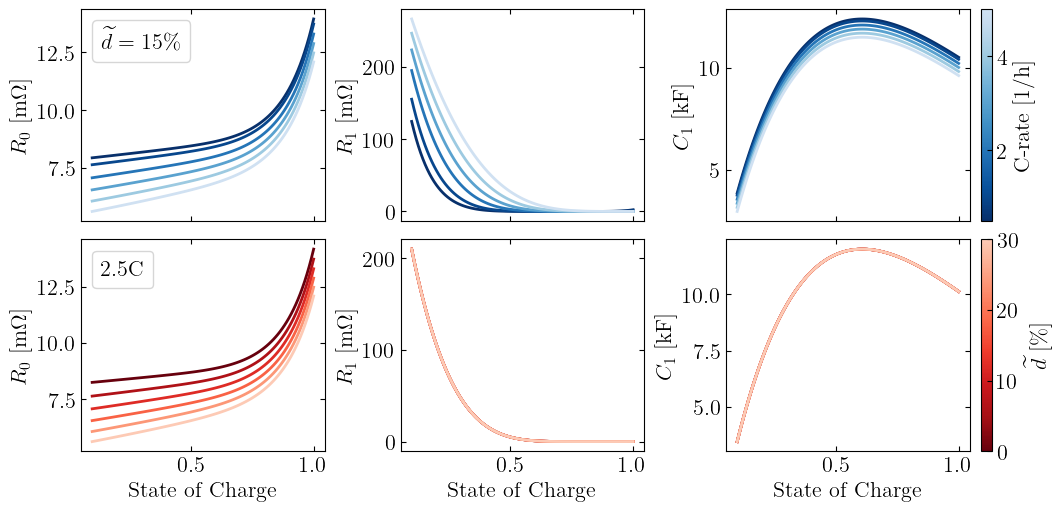

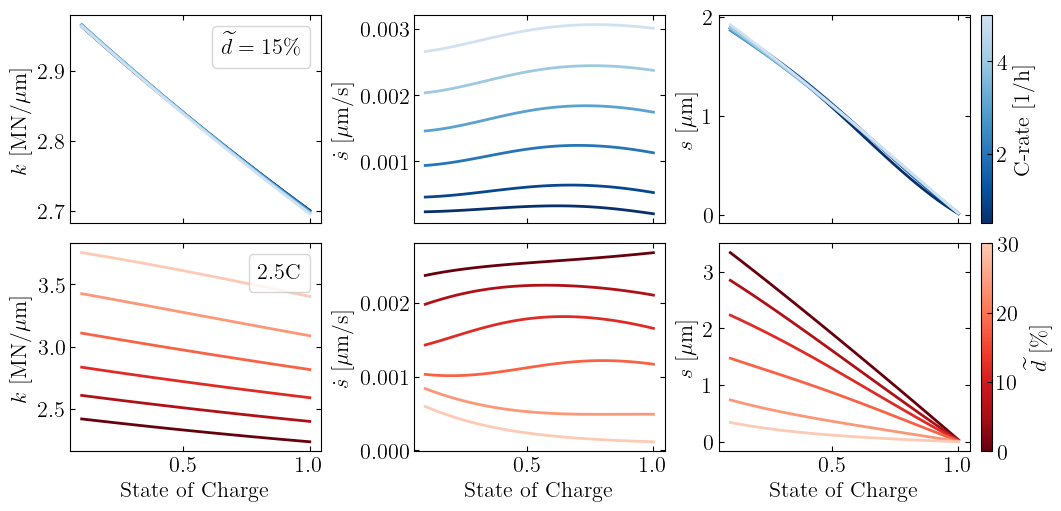

In [6]:
plot_element_grid(['R0', 'R1', 'C1'], models='nn', fixed_C=2.5, fixed_d=15)
plot_element_grid(['R0', 'R1', 'C1'], models='sr', fixed_C=2.5, fixed_d=15)
# plt.savefig(os.path.join('element_figs', f'grid_R0_R1_C1_nn_zoomed_{model_name}.pdf'), bbox_inches='tight')

plot_element_grid(['k', 'sdot', 's'], models='nn', fixed_C=2.5, fixed_d=15.0)
# # plt.savefig(os.path.join('element_figs', f'grid_k_sdot_s_nn_{model_name}.pdf'), bbox_inches='tight')
plt.show()

In [7]:
# Normalization the SR fits expect at their inputs.
# Update these if you retrain SR with a different feature range.
SR_C_NORM = 5.0     # c_rate trained on c_rate / 5
SR_D_NORM = 30.0    # u_per  trained on u_per  / 30


def _compute_element(element, c_rate, u_per, soc_t, source='nn'):
    """source ∈ {'nn','sr'}. s/sdot always use sdot_nn (no SR variant yet)."""
    # SR functions were trained on normalized inputs; NN handles its own norm.
    if source == 'sr':
        c_arg, u_arg = c_rate / REF_VALUES['C'], u_per / REF_VALUES['d']
        funcs = {'R0': R0_func, 'R1': R1_func, 'C1': C1_func, 'k': k_func}
    elif source == 'nn':
        c_arg, u_arg = c_rate, u_per
        funcs = {'R0': R0_nn, 'R1': R1_nn, 'C1': C1_nn, 'k': k_nn}
    else:
        raise ValueError(f"source must be 'nn' or 'sr', got {source!r}")

    if element in funcs:
        return funcs[element](c_arg, u_arg, soc_t)

    if element == 'tau':
        return (funcs['R1'](c_arg, u_arg, soc_t) * funcs['C1'](c_arg, u_arg, soc_t))

    if element in ('s', 'sdot'):
        # Integrate s in PHYSICAL units. Then return values in the convention
        # _draw_sweep expects:  NN → physical (×scale_nn at display);
        #                       SR → normalized (×scale_sr×scale_nn at display).
        s_curr = 0.0
        out = []
        dsoc = float(abs(soc_t[1] - soc_t[0]))
        dt = dsoc * 3600.0 / abs(c_rate)

        for soc_val in soc_t:
            if source == 'sr':
                s_in = s_curr / REF_VALUES['s']                       # state → normalized
                ds_norm = float(np.asarray(
                    sdot_func(c_arg, u_arg, soc_val, s_in)).squeeze())
                ds_phys = ds_norm * REF_VALUES['sdot']                # → physical for the integrator
            else:
                ds_phys = float(np.asarray(
                    sdot_nn(c_rate, u_per, soc_val, s_curr)).squeeze())
                if ds_phys < 0:
                    print(f"Negative ds_phys found for soc_val {soc_val}: {ds_phys}")

            if element == 'sdot':
                out.append(ds_phys / REF_VALUES['sdot'] if source == 'sr' else ds_phys)
            s_curr = s_curr + ds_phys * dt
            if s_curr < 0:
                print(f's_curr negative at soc_val {soc_val}: {s_curr}')
            if element == 's':
                out.append(s_curr / REF_VALUES['s'] if source == 'sr' else s_curr)

        return np.asarray(out)

    raise ValueError(f"unknown element {element!r}")


# ── per-axis draw, possibly two sources overlaid ────────────────────────
_LINESTYLE = {'nn': '--', 'sr': '-'}   # NN striped, SR solid

def _draw_sweep(ax, element, *, sweep, fixed, sweep_vals, soc_t,
                cmap_obj, norm, models='nn'):
    """models in {'nn','sr','both'}.  When 'both', NN is dashed, SR is solid."""
    scale_nn, ylabel = _ELEM_META[element]
    scale_sr = REF_VALUES[element]

    if models == 'both':
        sources = ['nn', 'sr']
    elif models in ('nn', 'sr'):
        sources = [models]
    else:
        raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")

    # If only one source, use solid regardless of which it is
    styles = _LINESTYLE if len(sources) == 2 else {sources[0]: '-'}

    for val in sweep_vals:
        c_rate, u_per = (fixed, val) if sweep == 'u_per' else (val, fixed)
        color = cmap_obj(norm(val))
        for src in sources:
            y = _compute_element(element, c_rate, u_per, soc_t, source=src)
            if src == 'nn':
                y_disp = y * scale_nn
            elif src == 'sr':
                y_disp = y * scale_sr * scale_nn

            ax.plot(soc_t.numpy(), y_disp, color=color, lw=2, linestyle=styles[src])

    ax.set_ylabel(ylabel)
    ax.ticklabel_format(useOffset=False, style='plain', axis='y')

def _make_cmap(name):
    base = {'Blues': plt.cm.Blues_r, 'Reds': plt.cm.Reds_r}[name]
    return LinearSegmentedColormap.from_list(
        f"{name}_custom", base(np.linspace(0.0, 0.8, 256)))

# ── grid orchestrator ───────────────────────────────────────────────────
def plot_element_grid_negative(elements, *, models='nn',
                      fixed_C=2.5, fixed_d=15.0,
                      d_sweep_vals=None, c_sweep_vals=None,
                      soc=None, figsize=None):
    """
    2  len(elements) grid.
        Top row    : fixed d, sweep C  (Blues, C-rate colorbar)
        Bottom row : fixed C, sweep d  (Reds,  d colorbar)
    models : 'nn' | 'sr' | 'both'.  When 'both', NN is dashed and SR is solid.
    """
    if models not in ('nn', 'sr', 'both'):
        raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")

    if d_sweep_vals is None:
        d_sweep_vals = np.linspace(0, 30, 5)
        # d_sweep_vals = np.linspace(-30, 30, 12)
    if c_sweep_vals is None:
        c_sweep_vals = np.array([-0.5, -1, -2, -3, -4, -5])
        # c_sweep_vals = np.linspace(-5.0, 0.0, 6)
    if soc is None:
        soc = np.linspace(0.1, 1.0, 100)
    soc_t = torch.as_tensor(soc, dtype=torch.float32)
    # print(soc_t)

    n = len(elements)
    if figsize is None:
        figsize = ((3.5 * n + 1) if n == 1 else (3.5 * n), 5)

    fig, axes = plt.subplots(2, n, figsize=figsize,
                              sharex=True, constrained_layout=True)
    if n == 1:
        axes = axes.reshape(2, 1)

    cmap_red, cmap_blue = _make_cmap('Reds'), _make_cmap('Blues')
    norm_d = Normalize(vmin=d_sweep_vals.min(), vmax=d_sweep_vals.max())
    norm_C = Normalize(vmin=c_sweep_vals.min(), vmax=c_sweep_vals.max())

    for j, elem in enumerate(elements):
        _draw_sweep(axes[1, j], elem, sweep='u_per', fixed=fixed_C,
                    sweep_vals=d_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_red, norm=norm_d, models=models)
        _draw_sweep(axes[0, j], elem, sweep='c_rate', fixed=fixed_d,
                    sweep_vals=c_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_blue, norm=norm_C, models=models)

    for ax in axes[1, :]:
        ax.set_xlabel('State of Charge')

    sm_d = ScalarMappable(cmap=cmap_red,  norm=norm_d); sm_d.set_array([])
    sm_C = ScalarMappable(cmap=cmap_blue, norm=norm_C); sm_C.set_array([])
    fig.colorbar(sm_d, ax=axes[1, :].tolist(),
                 label=r'$\widetilde{d}$ [\%]', location='right', pad=0.01)
    fig.colorbar(sm_C, ax=axes[0, :].tolist(),
                 label='C-rate [1/h]', location='right', pad=0.01)

    # Fixed-value tags
    axes[1, 0].legend(
        handles=[plt.Line2D([0], [0], color='none', label=fr'${fixed_C:g}$C')], loc='upper left', frameon=True, handlelength=0, handletextpad=0)
    axes[0, 0].legend(
        handles=[plt.Line2D([0], [0], color='none', label=fr'$\widetilde{{d}} = {fixed_d:g}\%$')],
        loc='upper left', frameon=True, handlelength=0, handletextpad=0)

    # Linestyle key — only when both sources are overlaid
    if models == 'both':
        axes[0, -1].legend(
            handles=[
                plt.Line2D([0], [0], color='gray', linestyle='--', lw=2, label='NN'),
                plt.Line2D([0], [0], color='gray', linestyle='-',  lw=2, label='SR'),
            ],
            loc='upper left', frameon=True)

    # axes[0, 0].invert_xaxis()
    axes[0, 0].set_xticks([.25, .50, .75, 1.0])
    return fig

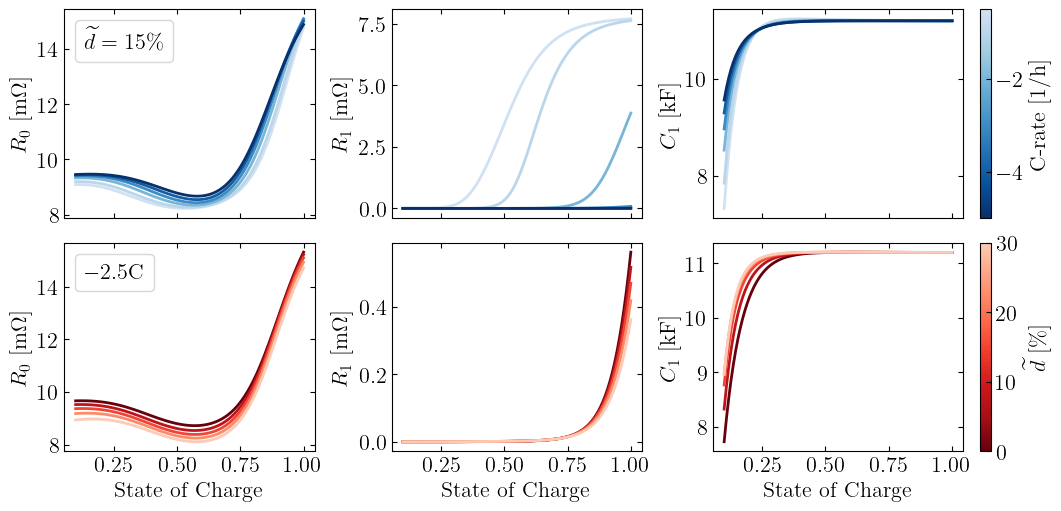

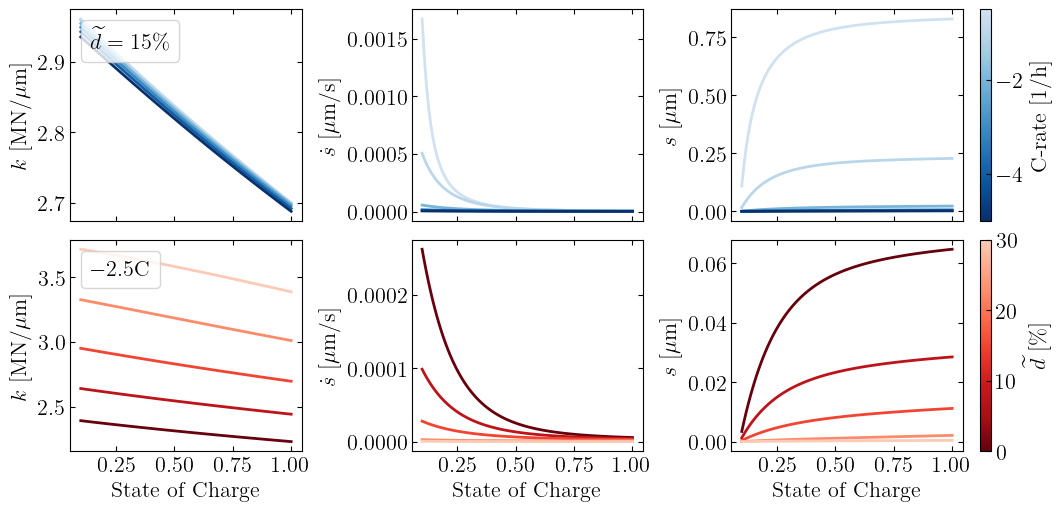

In [8]:

plot_element_grid_negative(['R0', 'R1', 'C1'], models='nn', fixed_C=-2.5, fixed_d=15.0)
#plt.savefig(os.path.join('element_figs', f'grid_R0_R1_C1_nn_negative_{model_name}.pdf'), bbox_inches='tight')
plt.show()


plot_element_grid_negative(['k', 'sdot', 's'], models='nn', fixed_C=-2.5, fixed_d=15.0)
# plt.savefig(os.path.join('element_figs', f'grid_k_sdot_s_nn_negative_{model_name}.pdf'), bbox_inches='tight')
plt.show()



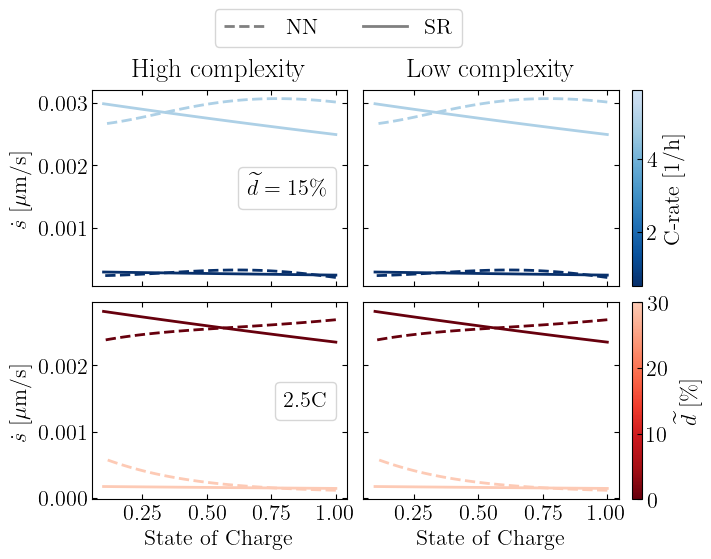

In [9]:
def _compute_element_comp(element, c_rate, u_per, soc_t, source='nn', sr_choice='preferred'):
    """source ∈ {'nn','sr'}. s/sdot always use sdot_nn (no SR variant yet)."""
    # SR functions were trained on normalized inputs; NN handles its own norm.
    if source == 'sr':
        c_arg, u_arg = c_rate / REF_VALUES['C'], u_per / REF_VALUES['d']
        if sr_choice == 'preferred':
            R0_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['R0'][best_SR['R0']], 'numpy')
            k_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['k'][best_SR['k']], 'numpy')
            R1_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['R1'][best_SR['R1']], 'numpy')
            C1_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['C1'][best_SR['C1']], 'numpy')
            funcs = {'R0': R0_func_chosen, 'R1': R1_func_chosen, 'C1': C1_func_chosen, 'k': k_func_chosen}
        elif sr_choice == 'simple':
            R0_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['R0'][chosen_SR['R0']], 'numpy')
            k_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['k'][chosen_SR['k']], 'numpy')
            R1_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['R1'][chosen_SR['R1']], 'numpy')
            C1_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['C1'][chosen_SR['C1']], 'numpy')
            funcs = {'R0': R0_func_chosen, 'R1': R1_func_chosen, 'C1': C1_func_chosen, 'k': k_func_chosen}
    elif source == 'nn':
        c_arg, u_arg = c_rate, u_per
        funcs = {'R0': R0_nn, 'R1': R1_nn, 'C1': C1_nn, 'k': k_nn}
    else:
        raise ValueError(f"source must be 'nn' or 'sr', got {source!r}")

    if element in funcs:
        return funcs[element](c_arg, u_arg, soc_t)

    if element == 'tau':
        return (funcs['R1'](c_arg, u_arg, soc_t) * funcs['C1'](c_arg, u_arg, soc_t))

    if element in ('s', 'sdot'):

        s_curr = 0.0
        out = []
        dsoc = float(abs(soc_t[1] - soc_t[0]))
        dt = dsoc * 3600.0 / c_rate
        if sr_choice == 'preferred':
            sdot_func = sp.lambdify(('C', 'd', 'soc', 's'), expressions['sdot'][best_SR['sdot']], 'numpy')
        elif sr_choice == 'simple':
            sdot_func = sp.lambdify(('C', 'd', 'soc', 's'), expressions['sdot'][chosen_SR['sdot']], 'numpy')
        

        for soc_val in soc_t:
            if source == 'sr':
                s_in = s_curr / REF_VALUES['s']                       # state → normalized
                ds_norm = float(np.asarray(sdot_func(c_arg, u_arg, soc_val, s_in)).squeeze())
                ds_phys = ds_norm * REF_VALUES['sdot']                # → physical for the integrator
            else:
                ds_phys = float(np.asarray(
                    sdot_nn(c_rate, u_per, soc_val, s_curr)).squeeze())

            if element == 'sdot':
                out.append(ds_phys / REF_VALUES['sdot'] if source == 'sr' else ds_phys)
            s_curr = s_curr + ds_phys * dt
            if element == 's':
                out.append(s_curr / REF_VALUES['s'] if source == 'sr' else s_curr)

        return np.asarray(out)

    raise ValueError(f"unknown element {element!r}")




def _draw_sweep_comp(ax, element, *, sweep, fixed, sweep_vals, soc_t,
                cmap_obj, norm, models='nn',sr_choice='preferred'):
    """models in {'nn','sr','both'}.  When 'both', NN is dashed, SR is solid."""
    scale_nn, ylabel = _ELEM_META[element]
    scale_sr = REF_VALUES[element]

    if models == 'both':
        sources = ['nn', 'sr']
    elif models in ('nn', 'sr'):
        sources = [models]
    else:
        raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")

    # If only one source, use solid regardless of which it is
    styles = _LINESTYLE if len(sources) == 2 else {sources[0]: '-'}

    for val in sweep_vals:
        c_rate, u_per = (fixed, val) if sweep == 'u_per' else (val, fixed)
        color = cmap_obj(norm(val))
        for src in sources:
            y = _compute_element_comp(element, c_rate, u_per, soc_t, source=src, sr_choice=sr_choice)
            if src == 'nn':
                y_disp = y * scale_nn
            elif src == 'sr':
                y_disp = y * scale_sr * scale_nn

            ax.plot(soc_t.numpy(), y_disp, color=color, lw=2, linestyle=styles[src])

    #ax.set_ylabel(ylabel)
    ax.ticklabel_format(useOffset=False, style='plain', axis='y')
# ── grid orchestrator ───────────────────────────────────────────────────
def compare_SR_NN(elements, *, models='nn',
                      fixed_C=2.5, fixed_d=15.0,
                      d_sweep_vals=None, c_sweep_vals=None,
                      soc=None, figsize=None, sr_choice = 'best'):
    """
    2  len(elements) grid.
        Top row    : fixed d, sweep C  (Blues, C-rate colorbar)
        Bottom row : fixed C, sweep d  (Reds,  d colorbar)
    models : 'nn' | 'sr' | 'both'.  When 'both', NN is dashed and SR is solid.
    """
    if models not in ('nn', 'sr', 'both'):
        raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")

    if d_sweep_vals is None:
        d_sweep_vals = np.linspace(0, 30, 6)
    if c_sweep_vals is None:
        c_sweep_vals = np.array([0.5, 1, 2, 3, 4, 5])
        # c_sweep_vals = np.linspace(0.0, 5.0, 6)
    if soc is None:
        soc = np.linspace(1.0, 0.1, 100)
    soc_t = torch.as_tensor(soc, dtype=torch.float32)

    n = len(elements)
    if n == 1 and sr_choice == 'both':
        n = 2
    if figsize is None:
        figsize = ((3.5 * n + 1) if n == 1 else (3.5 * n), 5)

    if sr_choice == 'both':
        fig, axes = plt.subplots(2, 2, figsize=figsize,
                                  sharex=True, constrained_layout=True, sharey='row')
    else: 
        fig, axes = plt.subplots(2, n, figsize=figsize,
                              sharex=True, constrained_layout=True)
    if n == 1:
        axes = axes.reshape(2, 1)

    cmap_red, cmap_blue = _make_cmap('Reds'), _make_cmap('Blues')
    norm_d = Normalize(vmin=0, vmax=30)
    norm_C = Normalize(vmin=0.5, vmax=5.9)
    if sr_choice == 'both':
        sr_choices = ['preferred', 'simple']
    else:
        sr_choices = [sr_choice]
    if len(sr_choices) == 2 and len(elements) == 1:

        for j, sr_choice in enumerate(sr_choices):
            elem = elements[0]
            _draw_sweep_comp(axes[1, j], elem, sweep='u_per', fixed=fixed_C,
                    sweep_vals=d_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_red, norm=norm_d, models=models, sr_choice=sr_choice)
            _draw_sweep_comp(axes[0, j], elem, sweep='c_rate', fixed=fixed_d,
                    sweep_vals=c_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_blue, norm=norm_C, models=models, sr_choice=sr_choice)
    else:
        for j, sr_choice in enumerate(sr_choices):
            for i, elem in enumerate(elements):
                _draw_sweep_comp(axes[1, i], elem, sweep='u_per', fixed=fixed_C,
                    sweep_vals=d_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_red, norm=norm_d, models=models, sr_choice=sr_choice)
                _draw_sweep_comp(axes[0, i], elem, sweep='c_rate', fixed=fixed_d,
                    sweep_vals=c_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_blue, norm=norm_C, models=models, sr_choice=sr_choice)
    

    for ax in axes[1, :]:
        ax.set_xlabel('State of Charge')
    titles = ['High complexity', 'Low complexity'] 
    for ij,ax in enumerate(axes[0, :]):
        
        ax.set_title(titles[ij] if len(sr_choices) == 2 else '', pad=10)
    for ax in axes[:, 0]:
        ax.set_ylabel(_ELEM_META[elements[0]][1] if len(elements) == 1 else '')
    sm_d = ScalarMappable(cmap=cmap_red,  norm=norm_d); sm_d.set_array([])
    sm_C = ScalarMappable(cmap=cmap_blue, norm=norm_C); sm_C.set_array([])
    fig.colorbar(sm_d, ax=axes[1, :].tolist(),
                 label=r'$\widetilde{d}$ [\%]', location='right', pad=0.01)
    fig.colorbar(sm_C, ax=axes[0, :].tolist(),
                 label='C-rate [1/h]', location='right', pad=0.01)

    # Fixed-value tags
    axes[1, 0].legend(
        handles=[plt.Line2D([0], [0], color='none', label=fr'${fixed_C:g}$C')], loc='best', frameon=True, handlelength=0, handletextpad=0)
    axes[0, 0].legend(
        handles=[plt.Line2D([0], [0], color='none', label=fr'$\widetilde{{d}} = {fixed_d:g}\%$')],
        loc='best', frameon=True, handlelength=0, handletextpad=0)

    # Linestyle key — only when both sources are overlaid
    if models == 'both':
        fig.legend(
            handles=[
                plt.Line2D([0], [0], color='gray', linestyle='--', lw=2, label='NN'),
                plt.Line2D([0], [0], color='gray', linestyle='-',  lw=2, label='SR')
            ], frameon=True, ncol = 2, loc='upper center', bbox_to_anchor=(0.475, 1.11))

    # axes[0, 0].invert_xaxis()
    axes[0, 0].set_xticks([.25, .50, .75, 1.0])


    return fig

el = ['sdot'] # ,'s']
choice = 'both' # 'preferred' or 'simple' or 'both'
compare_SR_NN(el, models='both', fixed_C=2.5, fixed_d=15, sr_choice=choice, c_sweep_vals=np.array([.5,5]), d_sweep_vals=np.linspace(0,30,2))
plt.show()